# Actividad 2 - Procesamiento de imágenes aplicado a una imagen GPS

**Nombre:Camilo Andres Ladino Morales**  
**ID: 29241238-K**  
**Fecha:24/05/2026**  

En esta actividad se trabaja con una imagen tipo mapa que contiene una trayectoria GPS degradada. El objetivo es aplicar herramientas básicas de procesamiento de imágenes: visualización, histograma, filtrado, estimación/remoción de fondo y transformada wavelet 2D tipo Haar.

**Importante:** esta actividad no incluye análisis de series temporales, predicción lineal, clasificación ni métricas de detección de objetos. Es una actividad corta de preparación para el Proyecto II.

In [1]:
!pip install scikit-image
!pip install scikit-image PyWavelets

In [2]:
# ==============================
# Importación de librerías
# ==============================

import numpy as np                                      # Librería principal para manejo de arreglos numéricos
import matplotlib                                        # Importación base de matplotlib para consultar la versión
import matplotlib.pyplot as plt                          # Librería para generar gráficos y visualizar imágenes

import skimage                                           # Importación base de scikit-image para consultar la versión
from skimage import io, color                            # Módulos para lectura y conversión de imágenes
from skimage import filters                              # Filtros espaciales como el gaussiano y la mediana
from skimage import restoration                          # Utilidades de restauración de imágenes
from skimage import exposure                             # Herramientas para contraste e histograma
from skimage import util                                 # Funciones auxiliares para imágenes

import pywt                                              # PyWavelets para transformadas wavelet

plt.rcParams['figure.figsize'] = (6, 6)                  # Tamaño por defecto de las figuras
plt.rcParams['image.cmap'] = 'gray'                      # Mapa de color por defecto en escala de grises

print("✅ Librerías importadas correctamente")           # Confirmación de carga correcta
print(f"NumPy: {np.__version__}")                        # Mostrar versión de NumPy
print(f"Matplotlib: {matplotlib.__version__}")          # Mostrar versión de Matplotlib
print(f"scikit-image: {skimage.__version__}")           # Mostrar versión de scikit-image
print(f"PyWavelets: {pywt.__version__}")                # Mostrar versión de PyWavelets


✅ Librerías importadas correctamente
NumPy: 2.4.4
Matplotlib: 3.10.8
scikit-image: 0.26.0
PyWavelets: 1.8.0


## 1. Leer un caso y visualizar la información disponible

Seleccione uno de los casos del conjunto de datos. Cargue y visualice:
- `case_000`,
- `map_background.png`,
- `gps_trace_clean.png`,
- `gps_trace_noisy.png`,
- `gps_trace_overlay.png`.

Explique brevemente qué información contiene cada imagen.

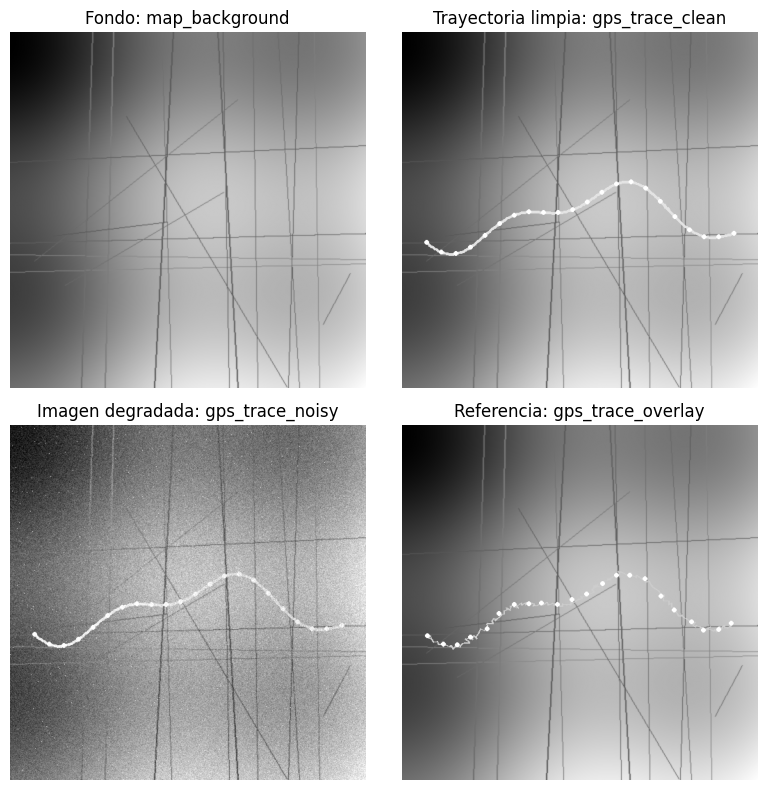

                                     
 Explicación de las imágenes:

1. map_background.png: Es la imagen base que representa el mapa del terreno o fondo, sin ninguna trayectoria dibujada. Muestra los gradientes de iluminación y estructuras propias del mapa.
2. gps_trace_clean.png: Muestra únicamente la trayectoria GPS ideal (limpia) trazada sobre un fondo neutro, sin ruido ni degradación.
3. gps_trace_noisy.png: Es la imagen degradada que debemos procesar. Contiene la trayectoria GPS, pero está afectada por ruido y montada sobre el fondo del mapa, lo que dificulta ver la ruta claramente.
4. gps_trace_overlay.png: Es una imagen de referencia que muestra la trayectoria limpia superpuesta sobre el mapa de fondo. Sirve como meta visual de lo que queremos lograr.



In [3]:
# ==============================
# 1. Leer un caso y visualizar la información disponible
# ==============================

map_background = io.imread('map_background.png')      # Imagen de fondo
gps_clean = io.imread('gps_trace_clean.png')         # Trayectoria limpia
gps_noisy = io.imread('gps_trace_noisy.png')         # Trayectoria degradada
gps_overlay = io.imread('gps_trace_overlay.png')     # Referencia: trayectoria limpia sobre el fondo

if map_background.ndim == 3:                          # Verificar si el fondo viene en RGB
    map_background = color.rgb2gray(map_background)  # Convertir a escala de grises

if gps_clean.ndim == 3:                               # Verificar si la trayectoria limpia viene en RGB
    gps_clean = color.rgb2gray(gps_clean)             # Convertir a escala de grises

if gps_noisy.ndim == 3:                               # Verificar si la imagen degradada viene en RGB
    gps_noisy = color.rgb2gray(gps_noisy)             # Convertir a escala de grises

if gps_overlay.ndim == 3:                             # Verificar si la referencia viene en RGB
    gps_overlay = color.rgb2gray(gps_overlay)         # Convertir a escala de grises

fig, axes = plt.subplots(2, 2, figsize=(8, 8))        # Crear una grilla 2x2 de subgráficos
ax = axes.ravel()                                     # Aplanar el arreglo de ejes

ax[0].imshow(map_background, cmap='gray')             # Mostrar la imagen de fondo
ax[0].set_title('Fondo: map_background')              # Título del primer panel
ax[0].axis('off')                                     # Ocultar ejes

ax[1].imshow(gps_clean, cmap='gray')                  # Mostrar la trayectoria limpia
ax[1].set_title('Trayectoria limpia: gps_trace_clean')# Título del segundo panel
ax[1].axis('off')                                     # Ocultar ejes

ax[2].imshow(gps_noisy, cmap='gray')                  # Mostrar la imagen degradada
ax[2].set_title('Imagen degradada: gps_trace_noisy')  # Título del tercer panel
ax[2].axis('off')                                     # Ocultar ejes

ax[3].imshow(gps_overlay, cmap='gray')                # Mostrar la imagen de referencia
ax[3].set_title('Referencia: gps_trace_overlay')      # Título del cuarto panel
ax[3].axis('off')                                     # Ocultar ejes

plt.tight_layout()                                    # Ajustar el espaciado entre figuras
plt.show()                                            # Mostrar la figura

explicacion = """                                     
 Explicación de las imágenes:

1. map_background.png: Es la imagen base que representa el mapa del terreno o fondo, sin ninguna trayectoria dibujada. Muestra los gradientes de iluminación y estructuras propias del mapa.
2. gps_trace_clean.png: Muestra únicamente la trayectoria GPS ideal (limpia) trazada sobre un fondo neutro, sin ruido ni degradación.
3. gps_trace_noisy.png: Es la imagen degradada que debemos procesar. Contiene la trayectoria GPS, pero está afectada por ruido y montada sobre el fondo del mapa, lo que dificulta ver la ruta claramente.
4. gps_trace_overlay.png: Es una imagen de referencia que muestra la trayectoria limpia superpuesta sobre el mapa de fondo. Sirve como meta visual de lo que queremos lograr.
"""                                                   

print(explicacion)                                    # Imprimir la explicación

## 2. Histograma de intensidad

Calcule y grafique el histograma de intensidad de `gps_trace_noisy.png`.

Discuta:

- qué rango de intensidades parece corresponder al fondo,
- qué rango podría corresponder a la trayectoria o a estructuras brillantes,
- por qué el histograma es útil antes de aplicar un umbral o una corrección de contraste.

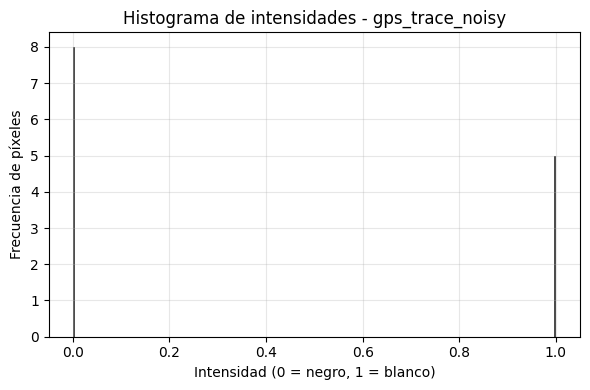

El histograma de la imagen gps_trace_noisy.png permite observar cómo se distribuyen los niveles de intensidad de todos los píxeles de la imagen. En esta caso, el rango de intensidades más concentrado suele corresponder al fondo del mapa, porque ocupa la mayor parte del área y presenta variaciones suaves de iluminación. Por otro lado, los valores más altos de intensidad pueden asociarse con la trayectoria GPS, con bordes más brillantes del mapa y también con algunos píxeles impulsivos generados por el ruido.

Este análisis es útil porque da una idea clara de qué tan separadas están las estructuras de interés respecto al fondo. Antes de aplicar un umbral, el histograma ayuda a estimar si existe una diferencia de intensidades suficiente para segmentar la trayectoria. Antes de aplicar una corrección de contraste, también permite decidir si la imagen necesita un realce global o si conviene trabajar sobre un rango específico de intensidades para destacar mejor la información relevante.


In [4]:
# ==============================
# 2. Histograma de intensidad
# ==============================

noisy_flat = gps_noisy.ravel()                        # Convertir la imagen a un vector 1D

num_bins = 256                                        # Definir el número de bins del histograma

plt.figure(figsize=(6, 4))                            # Crear la figura para el histograma

plt.hist(                                             # Graficar el histograma
    noisy_flat,                                       # Datos de entrada
    bins=num_bins,                                    # Número de bins
    range=(0, 1),                                     # Rango de intensidades
    color='black',                                    # Color de las barras
    alpha=0.7                                         # Transparencia
)

plt.xlabel('Intensidad (0 = negro, 1 = blanco)')      # Etiqueta del eje x
plt.ylabel('Frecuencia de píxeles')                   # Etiqueta del eje y
plt.title('Histograma de intensidades - gps_trace_noisy')  # Título del gráfico
plt.grid(True, alpha=0.3)                             # Activar la rejilla
plt.tight_layout()                                    # Ajustar márgenes
plt.show()                                            # Mostrar la figura

exp_hist = """El histograma de la imagen gps_trace_noisy.png permite observar cómo se distribuyen los niveles de intensidad de todos los píxeles de la imagen. En esta caso, el rango de intensidades más concentrado suele corresponder al fondo del mapa, porque ocupa la mayor parte del área y presenta variaciones suaves de iluminación. Por otro lado, los valores más altos de intensidad pueden asociarse con la trayectoria GPS, con bordes más brillantes del mapa y también con algunos píxeles impulsivos generados por el ruido.

Este análisis es útil porque da una idea clara de qué tan separadas están las estructuras de interés respecto al fondo. Antes de aplicar un umbral, el histograma ayuda a estimar si existe una diferencia de intensidades suficiente para segmentar la trayectoria. Antes de aplicar una corrección de contraste, también permite decidir si la imagen necesita un realce global o si conviene trabajar sobre un rango específico de intensidades para destacar mejor la información relevante."""
print(exp_hist)

## 3. Filtro gaussiano y filtro de mediana

Aplique un filtro gaussiano y un filtro de mediana a la imagen degradada.

Compare ambos resultados y explique:

- cuál reduce mejor el ruido suave,
- cuál es más efectivo frente a píxeles impulsivos,
- qué efectos no deseados pueden aparecer sobre bordes o estructuras delgadas.

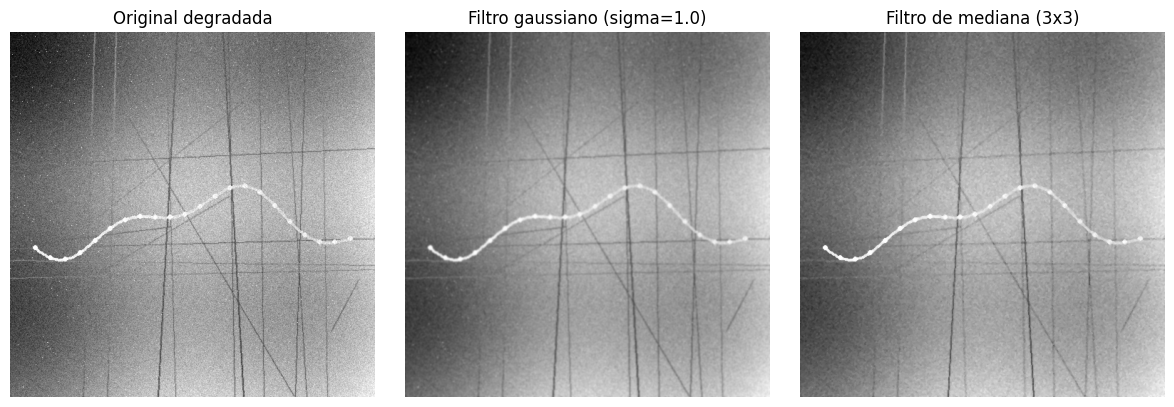

Al aplicar el filtro gaussiano y el filtro de mediana sobre la imagen degradada, se observa que ambos reducen el ruido, pero lo hacen de manera distinta. El filtro gaussiano es más adecuado para atenuar ruido suave o variaciones pequeñas de intensidad, porque promedia los valores de los píxeles cercanos y produce una imagen más suavizada. Sin embargo, ese mismo suavizado puede hacer que los bordes de la trayectoria y otras estructuras finas se vean menos definidas.

En cambio, el filtro de mediana es más efectivo frente a píxeles impulsivos o valores atípicos aislados, ya que reemplaza cada píxel por la mediana de su vecindario. Esto le permite eliminar puntos brillantes o oscuros aislados sin modificar tanto los bordes. Como efecto no deseado, si la ventana del filtro es muy grande, la mediana puede deformar detalles pequeños o adelgazar demasiado estructuras delgadas. Por eso, en esta imagen el filtro gaussiano ayuda más a suavizar el ruido general, mientras que el filtro de mediana 

In [5]:
# ==============================
# 3. Filtro gaussiano y filtro de mediana
# ==============================

gaussian_sigma = 1.0                                  # Sigma para el filtro gaussiano
median_size = 3                                       # Tamaño de la ventana de la mediana

gps_gaussian = filters.gaussian(                      # Aplicar filtro gaussiano
    gps_noisy,                                        # Imagen de entrada
    sigma=gaussian_sigma,                             # Desviación estándar del kernel
    preserve_range=True                                # Mantener el rango original de intensidades
)                                                     # Fin de la llamada al filtro

from skimage.morphology import footprint_rectangle    # Importar la función para crear el elemento estructurante

median_footprint = footprint_rectangle(               # Crear el footprint rectangular
    (median_size, median_size)                        # Tamaño 3x3 como tupla
)                                                     # Fin de la creación del footprint

gps_median = filters.median(                          # Aplicar filtro de mediana
    gps_noisy,                                        # Imagen de entrada
    footprint=median_footprint                        # Elemento estructurante
)                                                     # Fin de la llamada al filtro

fig, axes = plt.subplots(1, 3, figsize=(12, 4))       # Crear una figura con 3 subgráficos
ax = axes.ravel()                                     # Aplanar el arreglo de ejes

ax[0].imshow(gps_noisy, cmap='gray')                  # Mostrar la imagen degradada
ax[0].set_title('Original degradada')                 # Título del primer panel
ax[0].axis('off')                                     # Ocultar ejes del primer panel

ax[1].imshow(gps_gaussian, cmap='gray')               # Mostrar la imagen filtrada con gaussiano
ax[1].set_title(f'Filtro gaussiano (sigma={gaussian_sigma})')  # Título del segundo panel
ax[1].axis('off')                                     # Ocultar ejes del segundo panel

ax[2].imshow(gps_median, cmap='gray')                 # Mostrar la imagen filtrada con mediana
ax[2].set_title(f'Filtro de mediana ({median_size}x{median_size})')  # Título del tercer panel
ax[2].axis('off')                                     # Ocultar ejes del tercer panel

plt.tight_layout()                                    # Ajustar el espaciado entre subgráficos
plt.show()                                            # Mostrar la figura

exp_filtros = """Al aplicar el filtro gaussiano y el filtro de mediana sobre la imagen degradada, se observa que ambos reducen el ruido, pero lo hacen de manera distinta. El filtro gaussiano es más adecuado para atenuar ruido suave o variaciones pequeñas de intensidad, porque promedia los valores de los píxeles cercanos y produce una imagen más suavizada. Sin embargo, ese mismo suavizado puede hacer que los bordes de la trayectoria y otras estructuras finas se vean menos definidas.

En cambio, el filtro de mediana es más efectivo frente a píxeles impulsivos o valores atípicos aislados, ya que reemplaza cada píxel por la mediana de su vecindario. Esto le permite eliminar puntos brillantes o oscuros aislados sin modificar tanto los bordes. Como efecto no deseado, si la ventana del filtro es muy grande, la mediana puede deformar detalles pequeños o adelgazar demasiado estructuras delgadas. Por eso, en esta imagen el filtro gaussiano ayuda más a suavizar el ruido general, mientras que el filtro de mediana es mejor cuando existen píxeles aislados muy diferentes de su entorno."""
print(exp_filtros)                                   # Imprimir la explicación

## 4. Estimación y remoción de fondo

Estime un fondo suave $B(x,y)$ usando un filtro de gran escala. Luego calcule

$$
I_{\mathrm{corr}}(x,y)=I(x,y)-B(x,y).
$$

Muestre la imagen original degradada, el fondo estimado y la imagen corregida.

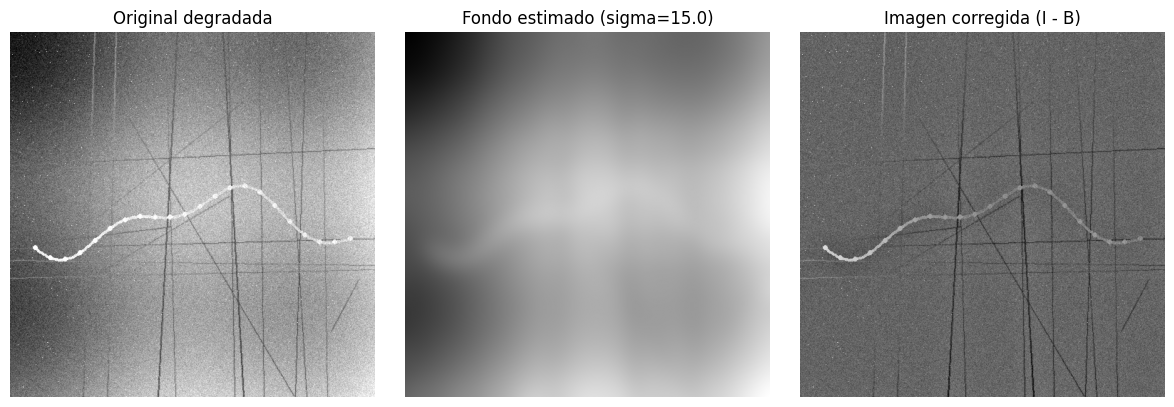

                                        


- El filtro gaussiano de gran escala permite estimar una versión muy suave del mapa.
- Al restar ese fondo, se reduce el gradiente global de iluminación y se resalta la trayectoria GPS.
- Este paso ayuda a separar estructuras finas de la variación lenta del fondo.



In [9]:
# ==============================
# 4. Estimación y remoción de fondo
# ==============================

background_sigma = 15.0                                # Sigma grande para estimar un fondo suave

background_est = filters.gaussian(                     # Aplicar filtro gaussiano de gran escala
    gps_noisy,                                         # Imagen degradada de entrada
    sigma=background_sigma,                            # Desviación estándar grande
    preserve_range=True                                # Mantener el rango original de intensidades
)                                                      # Fin del cálculo del fondo estimado

I_corr = gps_noisy - background_est                    # Restar el fondo estimado a la imagen original

I_corr_rescaled = exposure.rescale_intensity(          # Reescalar la imagen corregida
    I_corr                                             # Imagen resultante de la resta
)                                                      # Fin del reescalado

fig, axes = plt.subplots(1, 3, figsize=(12, 4))        # Crear una figura con 3 subgráficos
ax = axes.ravel()                                      # Aplanar el arreglo de ejes

ax[0].imshow(gps_noisy, cmap='gray')                   # Mostrar la imagen degradada original
ax[0].set_title('Original degradada')                  # Título del primer panel
ax[0].axis('off')                                      # Ocultar ejes del primer panel

ax[1].imshow(background_est, cmap='gray')              # Mostrar el fondo estimado
ax[1].set_title(f'Fondo estimado (sigma={background_sigma})')  # Título del segundo panel
ax[1].axis('off')                                      # Ocultar ejes del segundo panel

ax[2].imshow(I_corr_rescaled, cmap='gray')             # Mostrar la imagen corregida
ax[2].set_title('Imagen corregida (I - B)')            # Título del tercer panel
ax[2].axis('off')                                      # Ocultar ejes del tercer panel

plt.tight_layout()                                     # Ajustar el espaciado entre subgráficos
plt.show()                                             # Mostrar la figura

exp_fondo = """                                        


- El filtro gaussiano de gran escala permite estimar una versión muy suave del mapa.
- Al restar ese fondo, se reduce el gradiente global de iluminación y se resalta la trayectoria GPS.
- Este paso ayuda a separar estructuras finas de la variación lenta del fondo.
"""                                                    

print(exp_fondo)                                       # Imprimir la explicación

## 5. Transformada wavelet 2D tipo Haar

Implemente o aplique una transformada Haar 2D de un nivel para obtener las subbandas:

$$
I(x,y) \rightarrow \{LL,LH,HL,HH\}.
$$

Muestre las cuatro subbandas y reconstruya la imagen. Verifique visualmente que la reconstrucción sea consistente.

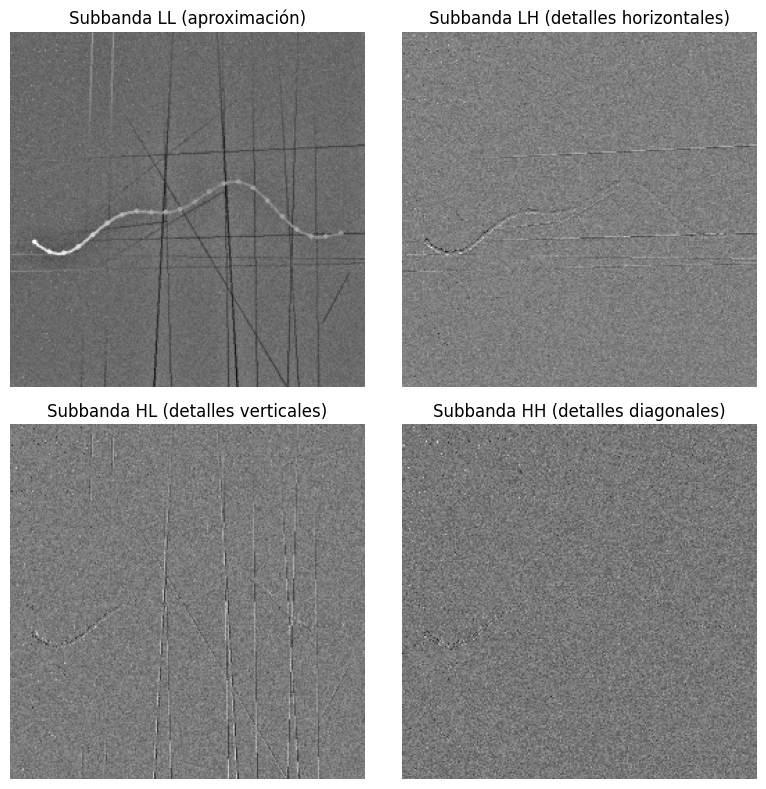

Error cuadrático medio de reconstrucción: 5.251990e-33


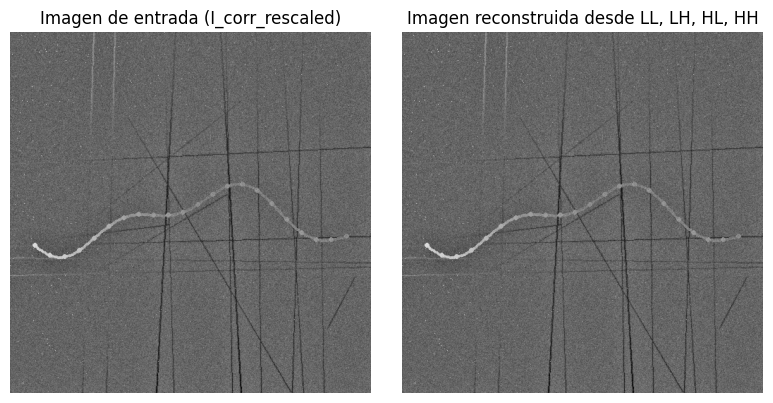

La transformada wavelet 2D tipo Haar permitió separar la imagen en una componente de aproximación (LL) y tres subbandas de detalle (LH, HL y HH). La subbanda LL concentra la información principal de la imagen, mientras que las demás subbandas capturan cambios horizontales, verticales y diagonales. Al reconstruir la imagen con la transformada inversa, el error cuadrático medio obtenido fue prácticamente cero (5.25e-33), lo que confirma que la descomposición y reconstrucción fueron consistentes y numéricamente correctas.


In [11]:
# ==============================
# 5. Transformada wavelet 2D tipo Haar
# ==============================

input_image = I_corr_rescaled                         # Usar la imagen corregida como entrada

coeffs2 = pywt.dwt2(input_image, 'haar')              # Aplicar la transformada Haar 2D
LL, (LH, HL, HH) = coeffs2                            # Desempaquetar subbandas

fig, axes = plt.subplots(2, 2, figsize=(8, 8))        # Crear una figura con 4 subgráficos
ax = axes.ravel()                                     # Aplanar el arreglo de ejes

ax[0].imshow(LL, cmap='gray')                         # Mostrar la subbanda LL
ax[0].set_title('Subbanda LL (aproximación)')         # Título de LL
ax[0].axis('off')                                     # Ocultar ejes de LL

ax[1].imshow(LH, cmap='gray')                         # Mostrar la subbanda LH
ax[1].set_title('Subbanda LH (detalles horizontales)')# Título de LH
ax[1].axis('off')                                     # Ocultar ejes de LH

ax[2].imshow(HL, cmap='gray')                         # Mostrar la subbanda HL
ax[2].set_title('Subbanda HL (detalles verticales)')  # Título de HL
ax[2].axis('off')                                     # Ocultar ejes de HL

ax[3].imshow(HH, cmap='gray')                         # Mostrar la subbanda HH
ax[3].set_title('Subbanda HH (detalles diagonales)')  # Título de HH
ax[3].axis('off')                                     # Ocultar ejes de HH

plt.tight_layout()                                    # Ajustar el espaciado
plt.show()                                            # Mostrar la figura

reconstructed = pywt.idwt2((LL, (LH, HL, HH)), 'haar') # Reconstruir la imagen desde las subbandas

mse = np.mean((input_image - reconstructed) ** 2)     # Calcular el error cuadrático medio

print(f'Error cuadrático medio de reconstrucción: {mse:.6e}')  # Imprimir el MSE

fig, axes = plt.subplots(1, 2, figsize=(8, 4))        # Crear dos subgráficos
ax = axes.ravel()                                     # Aplanar el arreglo de ejes

ax[0].imshow(input_image, cmap='gray')                # Mostrar la imagen de entrada
ax[0].set_title('Imagen de entrada (I_corr_rescaled)') # Título de la imagen de entrada
ax[0].axis('off')                                     # Ocultar ejes de entrada

ax[1].imshow(reconstructed, cmap='gray')              # Mostrar la imagen reconstruida
ax[1].set_title('Imagen reconstruida desde LL, LH, HL, HH')  # Título de la reconstruida
ax[1].axis('off')                                     # Ocultar ejes de la reconstruida

plt.tight_layout()                                    # Ajustar márgenes
plt.show()                                            # Mostrar la comparación

exp_haar = """La transformada wavelet 2D tipo Haar permitió separar la imagen en una componente de aproximación (LL) y tres subbandas de detalle (LH, HL y HH). La subbanda LL concentra la información principal de la imagen, mientras que las demás subbandas capturan cambios horizontales, verticales y diagonales. Al reconstruir la imagen con la transformada inversa, el error cuadrático medio obtenido fue prácticamente cero (5.25e-33), lo que confirma que la descomposición y reconstrucción fueron consistentes y numéricamente correctas."""
print(exp_haar)                                       # Imprimir la explicación

## 6. Comentario final

Escriba un comentario breve sobre qué herramienta fue más útil para mejorar la imagen y qué dificultad encontró al procesarla.

In [8]:
# ==============================
# 6. Comentario final
# ==============================

comentario_final = """En esta actividad, la herramienta más útil para mejorar la imagen fue la remoción de fondo, porque permitió disminuir el gradiente global del mapa y hacer que la trayectoria GPS destacara con mayor claridad. También fue importante combinarla con el filtro gaussiano y el filtro de mediana, ya que cada uno ayudó a tratar un tipo de degradación diferente: el gaussiano suavizó el ruido general y la mediana fue más adecuada para valores impulsivos o píxeles aislados.

La principal dificultad no fue solo el procesamiento de la imagen, sino también la correcta implementación del código en Jupyter Notebook. Por ejemplo, aparecieron errores al intentar convertir a escala de grises imágenes que ya estaban en ese formato, lo que mostró la importancia de verificar primero la dimensión de los datos. También se presentaron advertencias y errores al usar funciones de scikit-image que habían cambiado o que recibían parámetros de forma distinta, como ocurrió con la mediana y el elemento estructurante. Además, hubo que cuidar la sintaxis de los textos impresos con print para evitar errores de comillas o secuencias mal escritas.

En general, la actividad permitió entender que en procesamiento de imágenes no solo importa aplicar filtros, sino también interpretar correctamente el histograma, ajustar parámetros de filtrado y verificar cada paso del código antes de continuar. Eso hace que el resultado final sea más robusto y que la imagen procesada conserve mejor la trayectoria de interés."""
print(comentario_final)


En esta actividad, la herramienta más útil para mejorar la imagen fue la remoción de fondo, porque permitió disminuir el gradiente global del mapa y hacer que la trayectoria GPS destacara con mayor claridad. También fue importante combinarla con el filtro gaussiano y el filtro de mediana, ya que cada uno ayudó a tratar un tipo de degradación diferente: el gaussiano suavizó el ruido general y la mediana fue más adecuada para valores impulsivos o píxeles aislados.

La principal dificultad no fue solo el procesamiento de la imagen, sino también la correcta implementación del código en Jupyter Notebook. Por ejemplo, aparecieron errores al intentar convertir a escala de grises imágenes que ya estaban en ese formato, lo que mostró la importancia de verificar primero la dimensión de los datos. También se presentaron advertencias y errores al usar funciones de scikit-image que habían cambiado o que recibían parámetros de forma distinta, como ocurrió con la mediana y el elemento estructurante. 